In [3]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

##  CC & AARRR( 거래 플랫폼 데이터 )
- CC — Carrying Capacity (수용력/한계 성장)
생태학에서 빌려온 개념으로, 제품의 유저 수가 결국 도달하게 되는 **균형 상태(정상 상태)**
핵심 아이디어는 단순함. 매 기간 새로 유입되는 유저 수와 이탈하는 유저 수가 같아지는 지점이 곧 Carrying Capacity인데, 간단히 공식으로 표현하면 

  ***CC = 신규 유입 / 이탈률(Churn Rate)*** (이탈률 = 1 - Retention rate)

  예를 들어 매월 신규 유저가 1,000명 들어오고 월 이탈률이 10%라면, CC는 약 10,000명이 됨. 아무리 성장해도 이 천장을 넘기 어렵다는 뜻이고, CC를 높이려면 유입을 늘리거나 이탈을 줄여야 함.




----




- AAR — AARRR (Pirate Metrics) 프레임워크
Dave McClure가 제안한 유저 여정 분석 프레임워크로, 해적 지표라고도 불리는데, 단계별로 유저가 어디서 이탈하는지 퍼널 형태로 관찰하는 구조다.

  Acquisition(획득) → 유저가 제품을 처음 접하는 단계 (광고, 검색 유입 등)

  Activation(활성화) → 핵심 가치를 처음 경험하는 순간 (회원가입, 첫 구매, Aha moment)

  Retention(유지) → 유저가 반복적으로 돌아오는지

  Revenue(수익) → 실제 매출로 전환되는지

  Referral(추천) → 다른 사람에게 소개하는지

In [4]:
tb = pd.read_csv('../data/ecommerce_data.csv')

In [5]:
tb

,customer_id,join_dt,approved_dt,transaction_amt
0,1,2019-04-02,2024-09-24 05:23:09,34.57
1,2,2019-04-03,NaN,NaN
2,3,2019-04-02,NaN,NaN
3,4,2019-04-02,2024-10-20 14:45:53,9.93
4,4,2019-04-02,2024-10-23 16:14:14,15.71
...,...,...,...,...
441949,64208,2019-04-03,2024-11-25 15:55:38,7.00
441950,64208,2019-04-03,2024-11-26 21:35:41,0.57
441951,64209,2019-04-03,2024-09-08 12:15:53,0.86
441952,64209,2019-04-03,2024-10-11 12:47:38,12.14


In [6]:
tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441954 entries, 0 to 441953
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   customer_id      441954 non-null  int64  
 1   join_dt          441954 non-null  object 
 2   approved_dt      407198 non-null  object 
 3   transaction_amt  407198 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 13.5+ MB


1) 코호트 차팅 후 리텐션 정의

In [7]:
df = tb[tb.approved_dt.notnull()]
df['approved_dt'] = df['approved_dt'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d %H:%M:%S'))

In [8]:
df['transaction_week'] = df['approved_dt'].dt.to_period('W')
df['cohort_week'] = df.groupby('customer_id')['transaction_week'].transform('min')

In [9]:
# 코호트 기간 계산 
df['period'] = (df['transaction_week'] - df['cohort_week']).apply(lambda x: x.n)

In [12]:
# 코호트 테이블 생성
cohort_table = df.groupby(['cohort_week', 'period'])['customer_id'].nunique().unstack(fill_value=0)
cohort_table

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_week,,,,,,,,,,,,,,
2024-08-26/2024-09-01,3484,2774,2558,2562,2505,2535,2427,2277,2300,2324,2288,2274,2261,2129
2024-09-02/2024-09-08,9141,5375,5306,5173,5217,5027,4510,4749,4759,4820,4691,4791,4458,0
2024-09-09/2024-09-15,3841,1604,1451,1430,1492,1315,1328,1325,1358,1409,1394,1244,0,0
2024-09-16/2024-09-22,2626,921,844,789,739,799,734,735,763,815,710,0,0,0
2024-09-23/2024-09-29,1831,578,501,464,504,439,467,480,508,474,0,0,0,0
2024-09-30/2024-10-06,1553,385,315,324,386,362,340,346,324,0,0,0,0,0
2024-10-07/2024-10-13,1194,292,265,235,258,248,259,242,0,0,0,0,0,0
2024-10-14/2024-10-20,872,213,179,185,188,207,155,0,0,0,0,0,0,0
2024-10-21/2024-10-27,963,232,205,185,209,174,0,0,0,0,0,0,0,0


In [18]:
# 상대적 비율 계산
cohort_size = cohort_table.iloc[:,0]
retention_table = cohort_table.divide(cohort_size, axis=0)
retention_table

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_week,,,,,,,,,,,,,,
2024-08-26/2024-09-01,1.0,0.796211,0.734214,0.735362,0.719001,0.727612,0.696613,0.653559,0.660161,0.667049,0.656716,0.652698,0.648967,0.611079
2024-09-02/2024-09-08,1.0,0.588010,0.580462,0.565912,0.570725,0.549940,0.493381,0.519527,0.520621,0.527295,0.513182,0.524122,0.487693,0.000000
2024-09-09/2024-09-15,1.0,0.417600,0.377766,0.372299,0.388441,0.342359,0.345743,0.344962,0.353554,0.366832,0.362926,0.323874,0.000000,0.000000
2024-09-16/2024-09-22,1.0,0.350724,0.321401,0.300457,0.281417,0.304265,0.279513,0.279893,0.290556,0.310358,0.270373,0.000000,0.000000,0.000000
2024-09-23/2024-09-29,1.0,0.315674,0.273621,0.253413,0.275259,0.239760,0.255052,0.262152,0.277444,0.258875,0.000000,0.000000,0.000000,0.000000
2024-09-30/2024-10-06,1.0,0.247907,0.202833,0.208628,0.248551,0.233097,0.218931,0.222795,0.208628,0.000000,0.000000,0.000000,0.000000,0.000000
2024-10-07/2024-10-13,1.0,0.244556,0.221943,0.196817,0.216080,0.207705,0.216918,0.202680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-10-14/2024-10-20,1.0,0.244266,0.205275,0.212156,0.215596,0.237385,0.177752,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-10-21/2024-10-27,1.0,0.240914,0.212876,0.192108,0.217030,0.180685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# 주평균 획득(Acquisition) 유저 수 구하기
tb['join_dt'] = pd.to_datetime(tb['join_dt'])
tb['join_week'] = tb['join_dt'].dt.to_period('W')
inflow_tmp = tb.groupby('join_week')['customer_id'].nunique().reset_index()

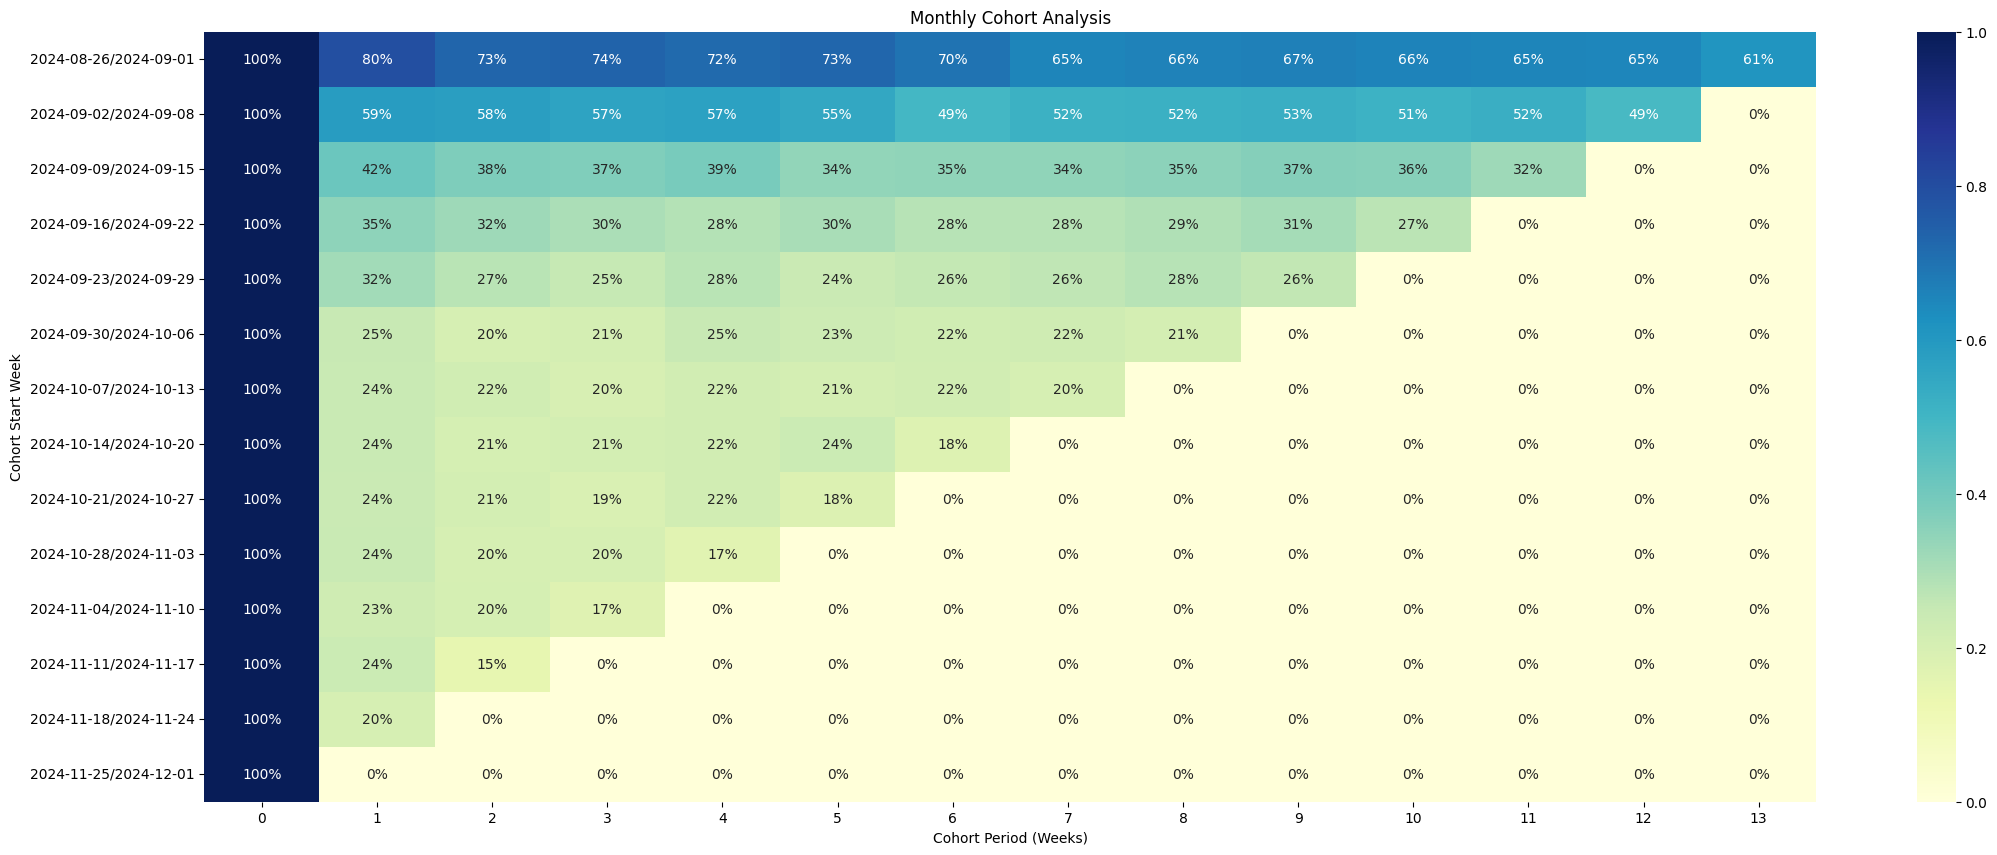

In [19]:
# 시각화
plt.figure(figsize=(26, 10))
sns.heatmap(retention_table, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Monthly Cohort Analysis")
plt.xlabel("Cohort Period (Weeks)")
plt.ylabel("Cohort Start Week")
plt.show()

### Inflow와 리텐션 및 이탈률을 구하고, cc 계산하기

In [25]:
# 주평균 획득(Acquisition) 유저 수 구하기
tb['join_dt'] = pd.to_datetime(tb['join_dt'])
tb['join_week'] = tb['join_dt'].dt.to_period('W')
inflow_tmp = tb.groupby('join_week')['customer_id'].nunique().reset_index()
inflow_tmp

,join_week,customer_id
0,2019-04-01/2019-04-07,30483
1,2019-04-08/2019-04-14,363
2,2019-04-15/2019-04-21,315
3,2019-04-22/2019-04-28,448
4,2019-04-29/2019-05-05,363
...,...,...
274,2024-07-01/2024-07-07,6
275,2024-07-08/2024-07-14,9
276,2024-07-15/2024-07-21,5
277,2024-07-22/2024-07-28,4


### 첫주 이후 inflow 변화가 궁금한데
  - 30483으로 첫주가 너무 크기때문에 스케일 조정을 위해 첫주 제외 시각화 

<Axes: >

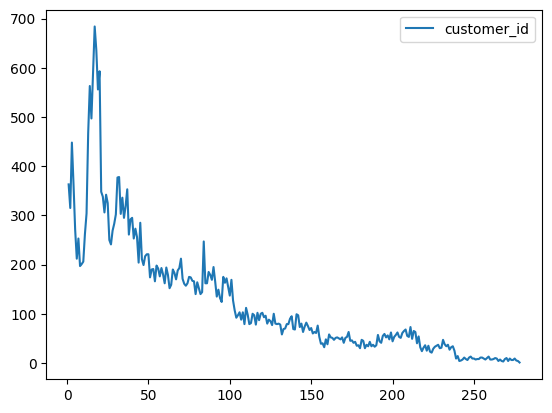

In [26]:
sns.lineplot(inflow_tmp.loc[1:, :])

In [27]:
inflow = inflow_tmp.customer_id.mean()
inflow

np.float64(230.14336917562724)

### 10/28 이전 데이터만 불러와서 전체 5주 리텐션 커브 확인

In [33]:
tmp = df.groupby('customer_id')['approved_dt'].min().reset_index()
tmp = tmp[tmp['approved_dt']<'2024-10-28']
tmp2 = df[df.customer_id.isin(tmp.customer_id.unique())]

retention_tmp = tmp2.groupby('period').customer_id.nunique() / tmp2.customer_id.nunique()
retention_tmp = retention_tmp.reset_index()
retention_tmp

,period,customer_id
0,0,1.000000
1,1,0.485160
2,2,0.455754
3,3,0.444893
4,4,0.450814
5,5,0.435444
6,6,0.400706
7,7,0.398118
8,8,0.392550
9,9,0.385885


<Axes: xlabel='period', ylabel='customer_id'>

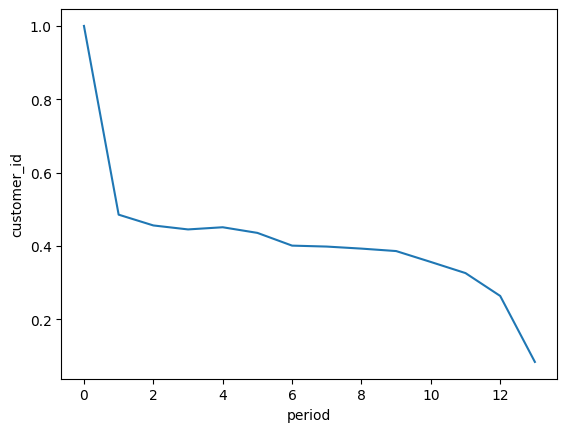

In [34]:
sns.lineplot(retention_tmp, x='period', y='customer_id')

### 2024 10 28 이전 가입한 전체 유저 첫주 Retention, CC 계산

In [35]:
retention = retention_tmp.loc[1][1]

# cc
cc = inflow / (1-retention)

print('평균 유입 : {}'.format(inflow))
print('전체 첫주 리텐션율: {}'.format(retention))
print('cc: {}'.format(cc))

평균 유입 : 230.14336917562724
전체 첫주 리텐션율: 0.4851597725936091
cc: 447.019010800729
